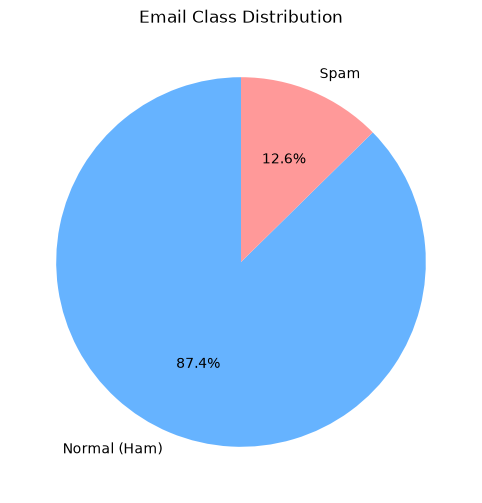

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

# Drop the empty junk columns and rename the good ones
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.columns = ['Label', 'Message']

# Remove duplicates to clean the data
df = df.drop_duplicates(keep='first')

# Convert text labels to numbers (0 for normal, 1 for spam)
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

# EDA: Class Distribution Pie Chart
plt.figure(figsize=(6, 6))
df['Label'].value_counts().plot(kind='pie', labels=['Normal (Ham)', 'Spam'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Email Class Distribution')
plt.ylabel('')
plt.show()

###  NLP Features & Grading Metrics

**What does TF-IDF measure?**
It measures how important a word is. It gives high scores to rare, meaningful words (like *Winner* or *Free*) and low scores to common, boring words (like *the* or *and*).

**Why is Recall important for spam detection?**
Recall measures how much of the actual spam we successfully caught. If our recall is low, it means dangerous junk emails are sneaking past the filter and getting into the user's main inbox!

=== NAIVE BAYES ===
Accuracy:  0.9662
Precision: 1.0000
Recall:    0.7586
F1-Score:  0.8627

=== LOGISTIC REGRESSION ===
Accuracy:  0.9642
Precision: 0.9821
Recall:    0.7586
F1-Score:  0.8560



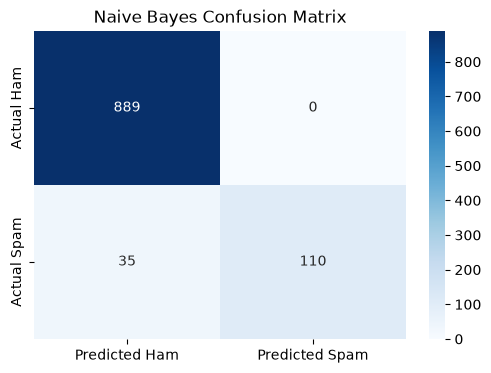

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train/Test Split (80/20)
X = df['Message']
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Text Preprocessing & Feature Extraction using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

def evaluate_model(model_name, y_true, y_pred):
    print(f"=== {model_name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}\n")

# Train & Evaluate Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
evaluate_model("NAIVE BAYES", y_test, nb_preds)

# Train & Evaluate Model 2: Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
evaluate_model("LOGISTIC REGRESSION", y_test, lr_preds)

# Draw Confusion Matrix for the best model (Naive Bayes)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Ham', 'Predicted Spam'], yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Naive Bayes Confusion Matrix')
plt.show()